## PCA ANALYSIS FOR PEX-A HOTSPOT

In [8]:
from re import search, compile
from spectrum_preprocessing import pipeline, distribution_Selection, roundWavenumbers
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import pickle as pk
import numpy as np
import os

numlike = compile(r"^-?\d+(\.\d+)?$")

Functions

In [9]:
def IR_PCA(input_data, PCs, normalize):

    scaler = StandardScaler()
    if normalize == True:
        input_data = scaler.fit_transform(input_data)
    else:
        pass
    
    pca = PCA(n_components = PCs)
    data_PCs = pca.fit_transform(input_data)
    columns_list = ['PC'+ str(x) for x in range(1, PCs+1)]
    PC_df = pd.DataFrame(data = data_PCs,
                                columns = columns_list)
    
    feature_weights = pca.components_
    loadings_df = pd.DataFrame(feature_weights)
    
    print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
    
    return(PC_df, loadings_df)

Import and Format Data

In [10]:
if not os.path.exists("C:/Users/Zach/Documents/GitHub/Feature Extraction/KMeans_Feature_Extraction/training_data.csv"):
        filepath = 'C:/Users/Zach/Documents/GitHub/betaVAE_Training/training_data/'

        #file2 = 'SMP65 010 0-100d Hotspot Spectra 800um.csv'
        allFiles = os.listdir(filepath)
        # Take only the files that contain data pertaining to SMP65#010 
        trainingFiles = [file for file in allFiles if file.endswith('.csv') and 'SMP65#010' in file and 'full width' not in file and 'hotspot' not in file]

        trainingFiles = sorted(trainingFiles, key=lambda x: int(search(r'(?<= )(.+?)(?=d)', x).group()))
        """
        trainingFiles =['SMP65#010 0d 820um.csv', 'SMP65#010 7d 820um.csv', 'SMP65#010 14d 820um.csv', 'SMP65#010 28d 820um.csv', 
                        'SMP65#010 42d 810um.csv', 'SMP65#010 56d 820um.csv', 'SMP65#010 70d 820um.csv', 'SMP65#010 100d 820um.csv']
        """
        
        print(trainingFiles)

        # Read all of the data and place the dataframes into a list
        trainingDataframeList = [pd.read_csv(filepath+file, low_memory=True, skiprows=[1,2]) for file in trainingFiles]

        masked_trainingDataframeList = []

        for df in trainingDataframeList:
                _, _, mask_selected, modePosition, areaPE = distribution_Selection(df, '1981.7 - 2095.8', 8)
                df[mask_selected] = df[mask_selected].ffill()
                masked_trainingDataframeList.append(df[mask_selected])
        trainingDataframeList = None # Clear memory

        rawTrainingDataframe = pd.concat(
        (
            df.rename(
                columns=lambda c: round(float(c), 1) if numlike.match(str(c).strip()) else c
            )
            for df in masked_trainingDataframeList
        ),
        ignore_index=True
        )

        training_df = pd.concat(masked_trainingDataframeList, ignore_index=True)
        training_df = roundWavenumbers(training_df)
        masked_trainingDataframeList = None # Clear memory of list of dataframes since we have one dataframe now

        numlike = compile(r"^-?\d+(\.\d+)?$")

        wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

        interpDataFramelist = []
        for index, full_row in training_df.iterrows():

                spectra = full_row[wavenumbers]
                metas = full_row.drop(wavenumbers)
                meta_cols = metas.index
                meta_values = metas.to_numpy()

                frequencies = spectra.index.to_numpy(dtype=float)
                frequencies = frequencies[::-1]  # Reverse the order for interpolation

                spectrum = spectra.to_numpy(dtype=float)
                spectrum = spectrum[::-1]  # Reverse the order for interpolation

                frequencies, spectrum = pipeline(frequencies, spectrum)

                cols = np.concatenate([meta_cols, frequencies])
                data = np.concatenate([meta_values, spectrum])

                interpDataFramelist.append(pd.DataFrame(data=[data], columns=cols))

        training_df = pd.concat(interpDataFramelist, ignore_index=True)
        
        wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

        frequencies = [float(wavenumber) for wavenumber in wavenumbers]

        training_df.to_csv("training_data.csv", index=False)

        grouped = training_df.groupby('Sample Name')

        keys = list(grouped.groups.keys())
        
        keys = sorted(keys, key=lambda s: int(search(r'(\d+)d', s).group(1)))

        print(keys)

        dfs = {key: grouped.get_group(key) for key in keys}

else:
        print("Training CSV File already exists.")
        filepath = "C:/Users/Zach/Documents/GitHub/Feature Extraction/KMeans_Feature_Extraction/training_data.csv"
        training_df = pd.read_csv(filepath, low_memory=True)

        numlike = compile(r"^-?\d+(\.\d+)?$")

        wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

        grouped = training_df.groupby('Sample Name')
        keys = list(grouped.groups.keys())
        
        keys = sorted(keys, key=lambda s: int(search(r'(\d+)d', s).group(1)))

        print(keys)

        dfs = {key: grouped.get_group(key) for key in keys}

legend_labels = training_df['Sample Name'].unique()
data_handles = []

Training CSV File already exists.
['0d 560um', '4d 820um', '7d 830um', '14d 830um', '21d 820um', '28d 830um', '35d 850um', '42d 810um', '49d 830um', '56d 820um', '63d 830um', '70d 820um', '77d 810um', '84d 820um', '100d 820um']


Individual Sample PCA

Explained variation per principal component: [0.30081839 0.15989605 0.13134766 0.08279753 0.0417709  0.03131021
 0.02838958 0.02566659 0.0175812  0.0148613 ]
Explained variation per principal component: [0.29820515 0.18060599 0.11976407 0.08644179 0.07389217 0.03606576
 0.02358057 0.01830384 0.01689611 0.01324968]
Explained variation per principal component: [0.2856169  0.18047951 0.10524308 0.08723949 0.07732531 0.03611577
 0.0321407  0.02427303 0.01649129 0.01326831]
Explained variation per principal component: [0.30734391 0.26942971 0.11227945 0.06237419 0.05161086 0.03059403
 0.02226758 0.01576331 0.01158723 0.01094243]
Explained variation per principal component: [0.32591418 0.18374475 0.12650768 0.06937806 0.04748733 0.03807585
 0.02473779 0.01997769 0.01515297 0.01254011]
Explained variation per principal component: [0.43295825 0.15645773 0.07728297 0.06636345 0.02911973 0.02168145
 0.01886224 0.01527282 0.0133495  0.01185937]
Explained variation per principal component: [0.4135

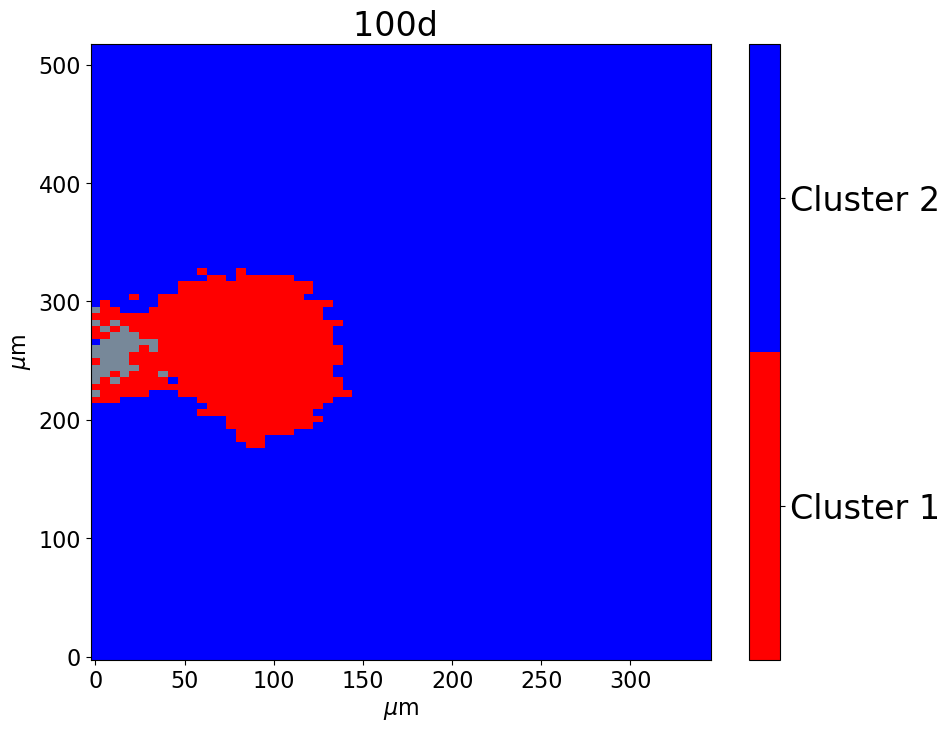

C:\Users\Zach\AppData\Local\Temp\ipykernel_16772\20484716.py:130: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for coll in contour.collections:
C:\Users\Zach\AppData\Local\Temp\ipykernel_16772\20484716.py:145: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  return contour.collections + [sc, ]
C:\Users\Zach\AppData\Local\Temp\ipykernel_16772\20484716.py:130: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for coll in contour.collections:
C:\Users\Zach\AppData\Local\Temp\ipykernel_16772\20484716.py:145: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  return contour.collections + [sc, ]


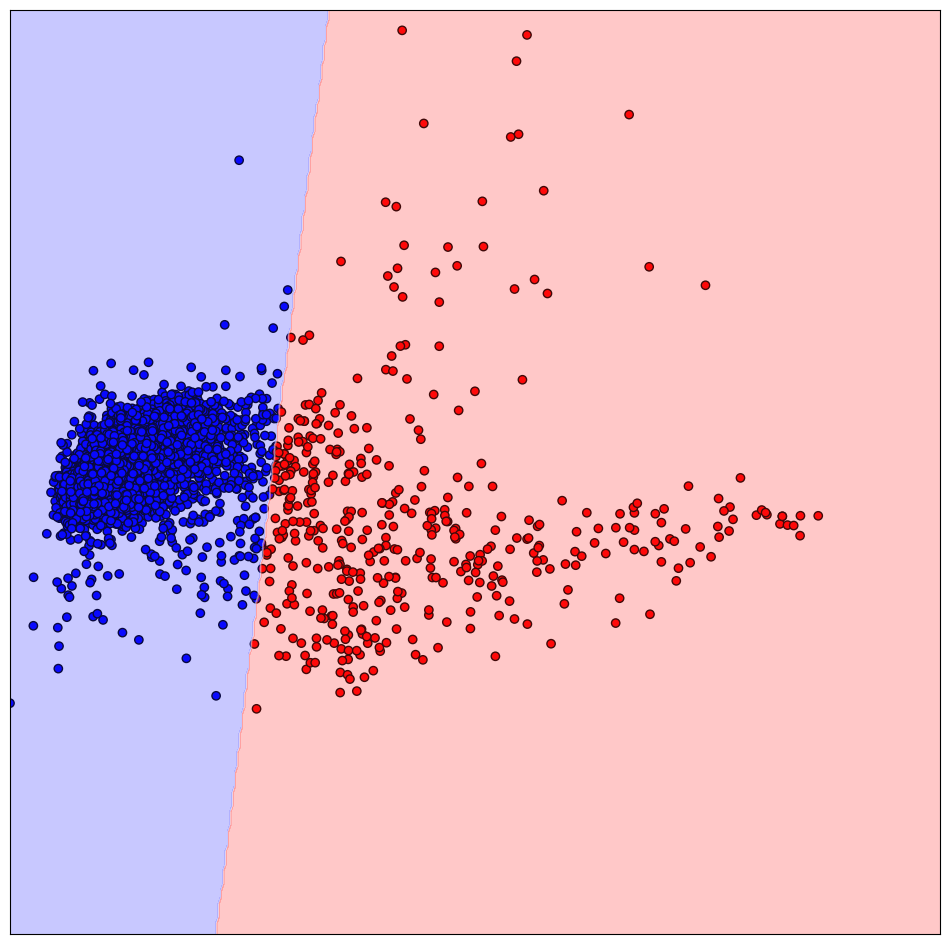

In [ ]:
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
from sklearn.cluster import KMeans
os.environ["OMP_NUM_THREADS"] = "2" # Defining number of threads to avoid memory leak in Kmeans on Windows
from sklearn.metrics import silhouette_score

def animate(i, x_vals, y_vals):
    plt.cla()
    plt.plot(x_vals, y_vals)

list_of_labels = {}
Z_list = []*len(keys)
Z_PC_list = []*len(keys)
for i, key in enumerate(keys):
    training_df = dfs[key]
    #Reposition the mapping to start at 0,0 
    Map_x = training_df['map_x'].to_numpy()
    Map_y = training_df['map_y'].to_numpy()
    Map_y2 = []
    Map_x2 = []
    Min_x = min(Map_x)
    Min_y = min(Map_y)

    Map_x2 = Map_x - Min_x
    Map_y2 = Map_y - Min_y

    training_df.loc[:, 'map_x'] = Map_x2
    training_df.loc[:, 'map_y'] = Map_y2

    x_unique = np.sort(training_df["map_x"].unique())
    y_unique = np.sort(training_df["map_y"].unique())

    X, Y = np.meshgrid(x_unique, y_unique)

    PCs=10

    PC_inputData = training_df[wavenumbers].copy()

    PCA_output = IR_PCA(PC_inputData, PCs, normalize=True)

    PC_df = PCA_output[0]
    loadings_df = PCA_output[1]

    kmeans = KMeans(n_clusters=2, random_state=42).fit(PC_df.values)
    labels = kmeans.fit_predict(PC_df)
    # Arange the clusters by the consumption level, or the amount of data points the cluster contains
    cluster_sizes = np.bincount(labels)
    idx = np.argsort(cluster_sizes)
    lut = np.zeros_like(idx)
    lut[idx] = np.arange(2)

    training_df = training_df.copy()
    training_df["cluster"] = lut[labels]
    dfs[key] = training_df

    Z_list.append(training_df.pivot(index="map_y", columns="map_x", values="cluster").sort_index(ascending=True).values)

    """
    Plot showing KMeans Clustering With Different Shaded Regions
    """

    X_scatter = PC_df[['PC1', 'PC2']].values

    kmeans = KMeans(n_clusters=2, random_state=42)
    labels = kmeans.fit_predict(X_scatter)

    x_min, x_max = PC_df['PC1'].min(), PC_df['PC1'].max()
    y_min, y_max = PC_df['PC2'].min(), PC_df['PC2'].max()

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(5*y_min, y_max, 400)
    )

    Z_PC_list.append(kmeans.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape))
    
cmap = mcolors.ListedColormap(['red', 'blue'])

fig, ax = plt.subplots(figsize=(10, 8))

# Initial frame
mesh = ax.pcolormesh(
    X,
    Y,
    Z_list[0],
    shading="auto",
    cmap=cmap
)

# ONE colorbar only
cbar = plt.colorbar(mesh, ax=ax)

cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['Cluster 1', 'Cluster 2'], fontsize=24)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.set_xlabel(f'$\mu$m', fontsize=16)
ax.set_ylabel(f'$\mu$m', fontsize=16)
ax.set_facecolor('lightslategray')

# Optional titles for each frame
titles = [f"{key[:-5]}" for key in keys]

def animate(frame):

    # Update mesh values
    mesh.set_array(Z_list[frame].ravel())

    # Update title
    ax.set_title(titles[frame], fontsize=24)

    return mesh,

ani = FuncAnimation(fig, animate, frames=len(Z_list), interval=800, blit=False, repeat=False)
ani.save("./clusters_hyperspectra.gif", writer='pillow')
plt.show()

"""
Example Contour plots of KMeans Clustering for Each Dataset

"""

fig, ax = plt.subplots(figsize=(12, 12))
def animate(frame):
    global contour

    # remove old contour
    for coll in contour.collections:
        coll.remove()

    # draw new contour
    contour = ax.contourf(
        xx,
        yy,
        Z_PC_list[frame],
        cmap='bwr',
        alpha=0.25
    )

    # update title
    #title.set_text(titles[frame])

    return contour.collections + [sc, ]

# static scatter
sc = ax.scatter(
    PC_df['PC1'],
    PC_df['PC2'],
    c=labels,
    cmap='bwr',
    edgecolors='k'
)

ax.set_ylim([-100,100])
ax.set_ylabel("PC2", fontsize=24)
ax.set_xlabel("PC1", fontsize=24)
ax.set_yticks([])
ax.set_xticks([])

contour = ax.contourf(xx, yy, Z_PC_list[0], cmap='bwr', alpha=0.25)

title = ax.set_title("Example KMeans Clustering", fontsize=24)

ani = FuncAnimation(
    fig,
    animate,
    frames=len(Z_PC_list),
    interval=800,
    blit=True
    #repeat=False
)

ani.save("kmeans_scatterplot.gif", writer="pillow")
plt.show()


Plot Average Spectra of Clusters

In [46]:
cluster1_spectra = []
cluster2_spectra = []

plot = False

for key in keys: 
    training_df = dfs[key]

    clustered_df = training_df.groupby('cluster').mean(numeric_only=True)

    clustered_spectra = clustered_df[wavenumbers]
    frequencies = wavenumbers.astype(float)

    cluster1_spectra.append(clustered_spectra.values[0].astype(float))
    cluster2_spectra.append(clustered_spectra.values[1].astype(float))
    if plot == True:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.set_ylabel('Absorbance', fontsize=18)
        ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
        ax.set_title(key[:-5], fontsize=18)
        ax.plot(frequencies, clustered_spectra.values[0].astype(float), color='r', linewidth=3)
        ax.plot(frequencies, clustered_spectra.values[1].astype(float), color='b', linewidth=3)
        
        ax.tick_params(which='major', axis='x', labelsize=18)
        ax.tick_params(which='minor', axis='x', length=5)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
        ax.legend(labels=['Cluster 1', 'Cluster 2'],
                fontsize=18, loc='upper left', 
                bbox_to_anchor=(0.7, 0.5, 0.5, 0.5))
        ax.tick_params(axis='y', labelsize=0)

        ax.set_xlim(frequencies[-1], frequencies[0])
        ax.grid(True)

Plotting the spectra of each Cluster as a Function of Time

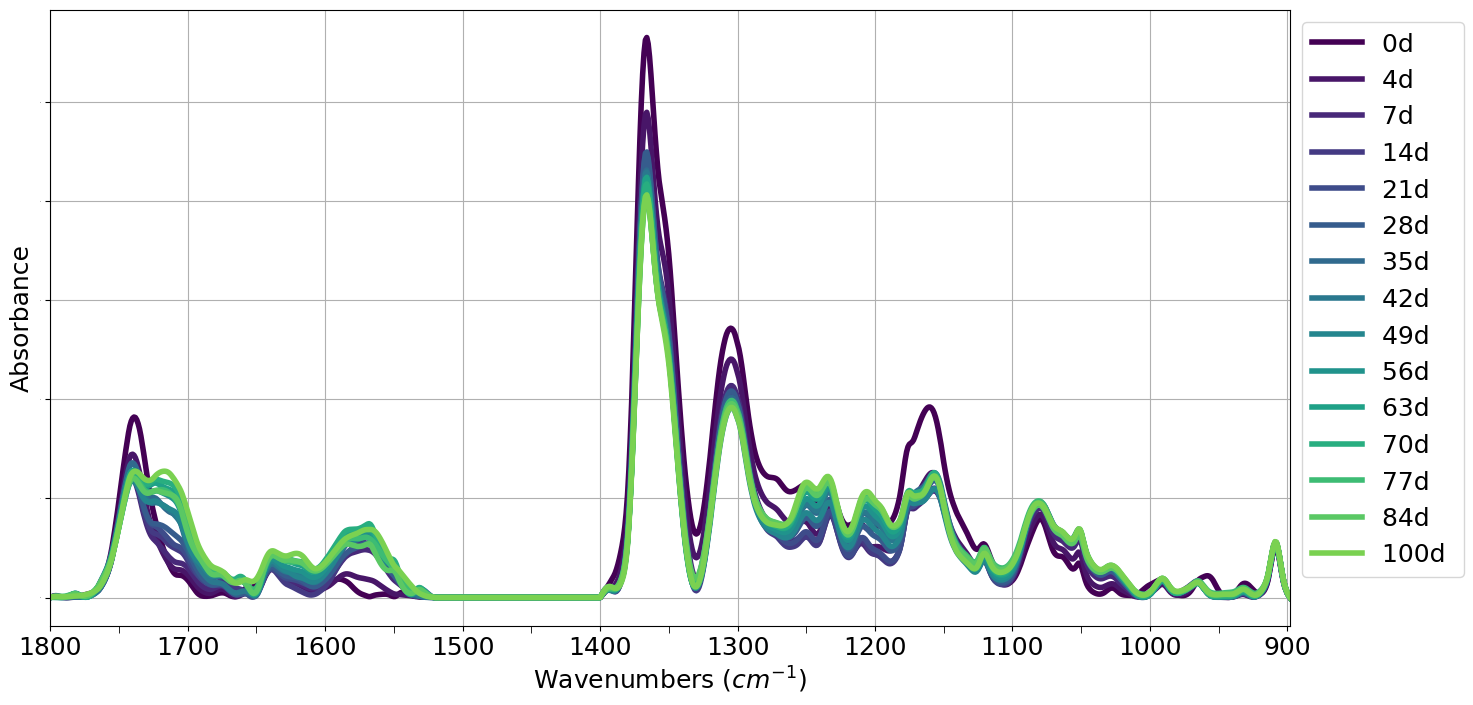

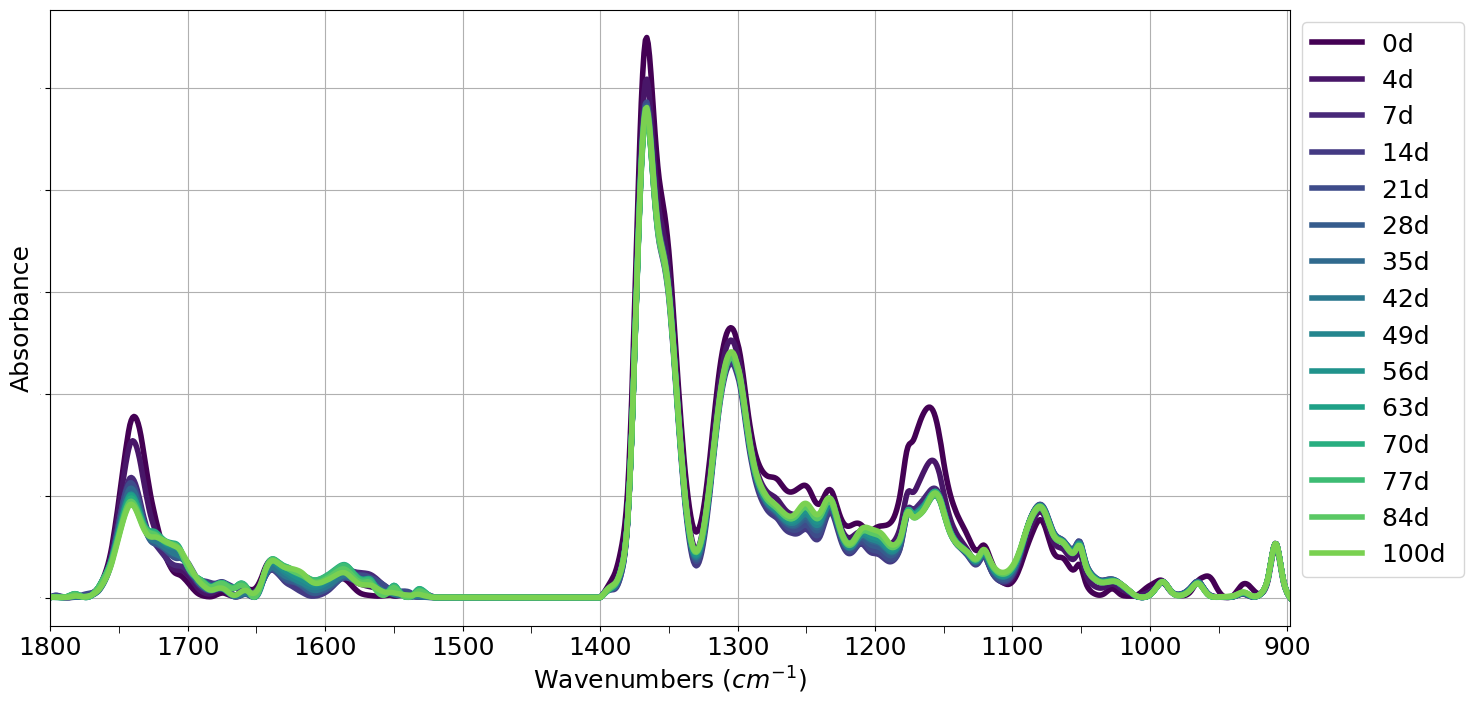

In [47]:
fig, ax = plt.subplots(figsize=(16, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster1_spectra)))

ax.set_ylabel('Absorbance', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
#ax.set_title("Cluster 1 Spectra", fontsize=18)

for i in range(len(cluster1_spectra)):
        ax.plot(frequencies, cluster1_spectra[i], color=colors[i], linewidth=4)

ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.legend(labels=[key[:-5] for key in keys],
        fontsize=18, loc='upper right', 
        bbox_to_anchor=(0.65, 0.5, 0.5, 0.5))
ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.grid(True)
plt.savefig('hotspot_spectra.png', bbox_inches='tight')

fig, ax = plt.subplots(figsize=(16, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster2_spectra)))

ax.set_ylabel('Absorbance', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
#ax.set_title("Cluster 2 Spectra", fontsize=18)

for i in range(len(cluster2_spectra)):
        ax.plot(frequencies, cluster2_spectra[i], color=colors[i], linewidth=4)

ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.legend(labels=[key[:-5] for key in keys],
        fontsize=18, loc='upper right', 
        bbox_to_anchor=(0.65, 0.5, 0.5, 0.5))
ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.grid(True)
plt.savefig('bulk_spectra.png', bbox_inches='tight')

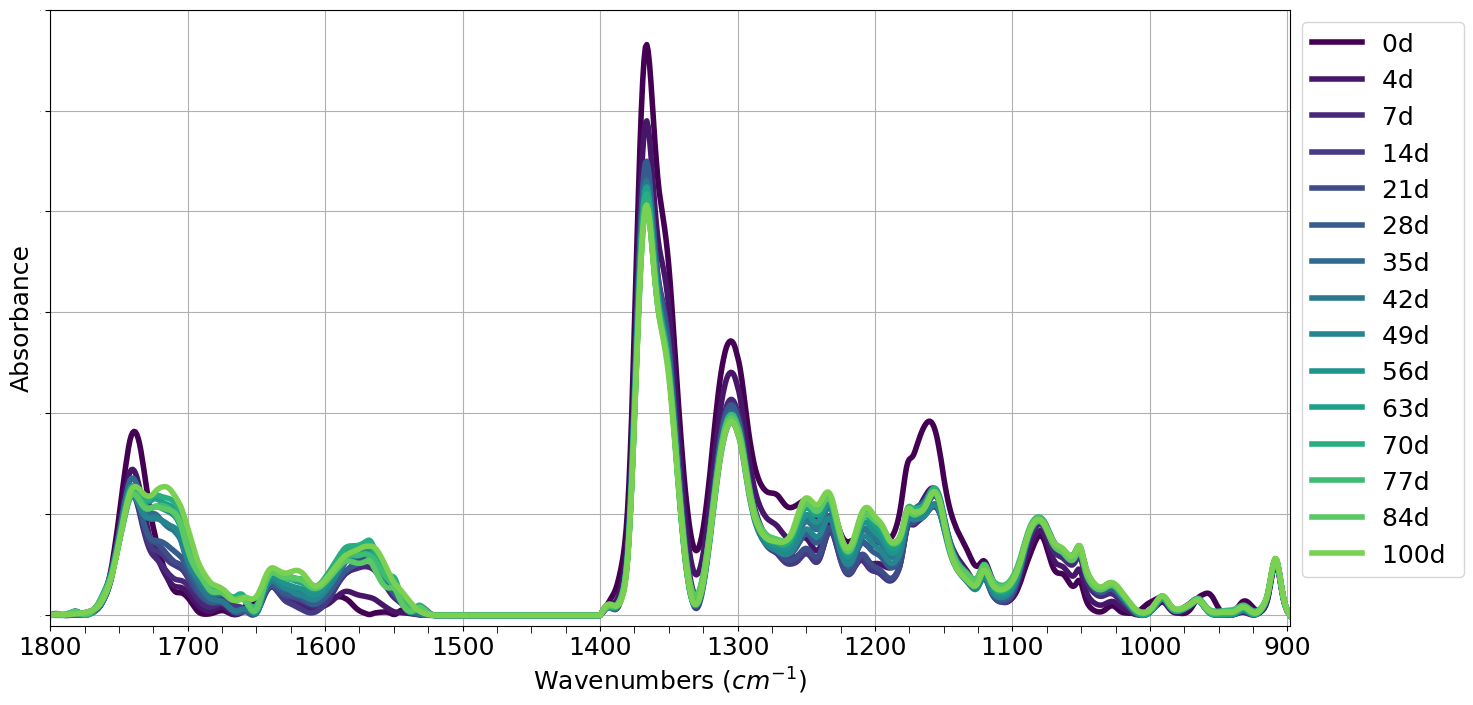

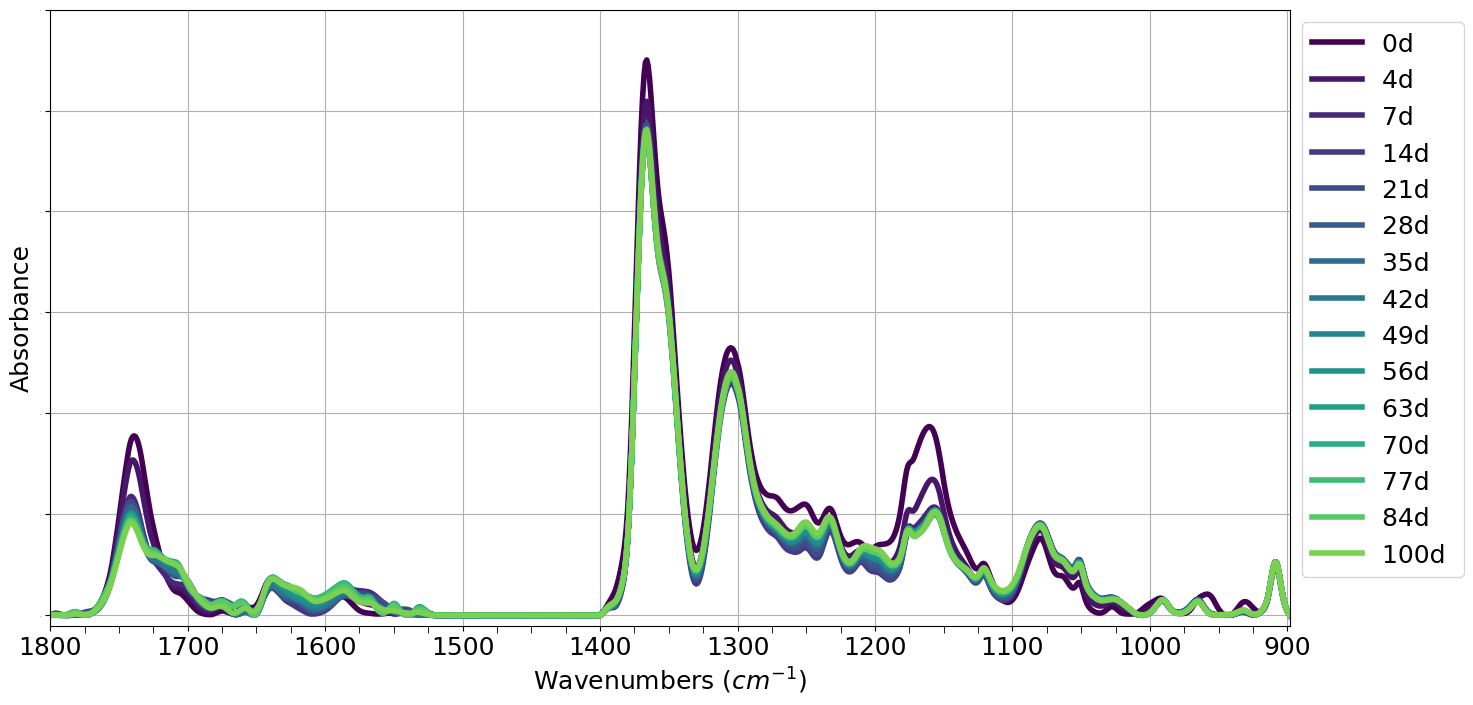

In [48]:
from matplotlib.animation import FuncAnimation
"""
Animation for the Cluster Associated with the Hotspot

"""
fig, ax = plt.subplots(figsize=(16, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster1_spectra)))

ax.set_ylabel('Absorbance', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)

ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))

ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.set_ylim([-0.1, 6])
ax.grid(True)

lines = []
for _ in range(len(keys)):
    line, = ax.plot([], [], linewidth=4)
    lines.append(line)

def animate(frame):
        lines[frame].set_data(frequencies, cluster1_spectra[frame])
        lines[frame].set_color(colors[frame])
        lines[frame].set_label(keys[frame][:-5])
        ax.legend(fontsize=18, loc='upper right', 
        bbox_to_anchor=(0.65, 0.5, 0.5, 0.5))
        return lines[frame], 

ani = FuncAnimation(fig=fig, func=animate, interval=800, frames=len(keys), blit=False, repeat=False)
ani.save("./hotspot_spectra.gif", writer="pillow")

"""
Animation for the Cluster Associated with the Bulk

"""
fig, ax = plt.subplots(figsize=(16, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster2_spectra)))

ax.set_ylabel('Absorbance', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))

ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.set_ylim([-0.1, 6])
ax.grid(True)

lines = []
for _ in range(len(keys)):
    line, = ax.plot([], [], linewidth=4)
    lines.append(line)

def animate(frame):
        lines[frame].set_data(frequencies, cluster2_spectra[frame])
        lines[frame].set_color(colors[frame])
        lines[frame].set_label(keys[frame][:-5])
        ax.legend(fontsize=18, loc='upper right', 
        bbox_to_anchor=(0.65, 0.5, 0.5, 0.5))
        return lines[frame], 

ani = FuncAnimation(fig=fig, func=animate, interval=800, frames=len(keys), blit=False, repeat=False)
ani.save("./bulk_spectra.gif", writer="pillow")


Hyperspectra of PCA 

Explained variation per principal component: [0.46258858 0.17182133 0.10547988 0.07277958 0.02866823 0.01942494
 0.01563484 0.01349026 0.01034044 0.00897996]
Explained variation per principal component: [0.61961315 0.15679485 0.09571329 0.03572333 0.02483282 0.01873247
 0.00761192 0.00483165 0.00403503 0.00278232]
Explained variation per principal component: [0.61755212 0.14411391 0.07522506 0.04150013 0.03540486 0.0306607
 0.00786463 0.00594625 0.00469932 0.0035534 ]
Explained variation per principal component: [0.6189916  0.18822539 0.05972355 0.04500752 0.02400504 0.01219243
 0.01141325 0.00551438 0.00423559 0.00276152]
Explained variation per principal component: [0.64900086 0.13797555 0.08822463 0.0402703  0.02284923 0.01614178
 0.00755978 0.00470798 0.00378146 0.00271331]
Explained variation per principal component: [0.760241   0.1133721  0.03803396 0.02748674 0.01249309 0.01054784
 0.00625201 0.00379417 0.00161893 0.00155183]
Explained variation per principal component: [0.63678

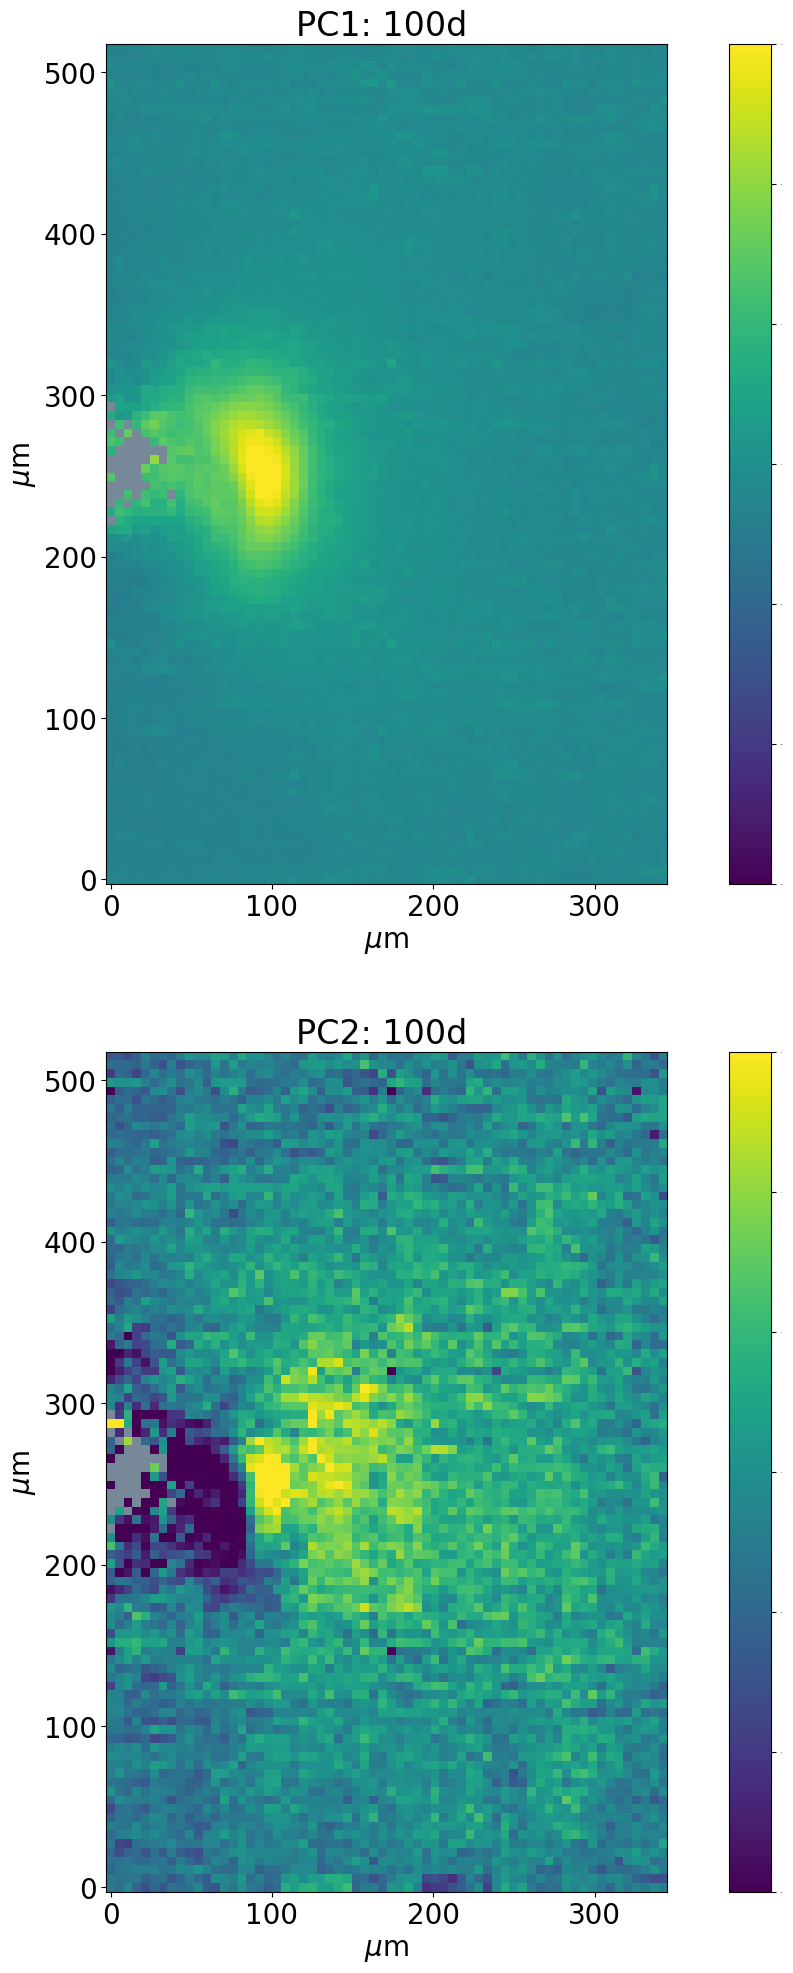

In [49]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
PC1_list = []*len(keys)
PC2_list = []*len(keys)

for i, key in enumerate(keys):
    training_df = dfs[key]
    #Reposition the mapping to start at 0,0 
    Map_x = training_df['map_x'].to_numpy()
    Map_y = training_df['map_y'].to_numpy()
    Map_y2 = []
    Map_x2 = []
    Min_x = min(Map_x)
    Min_y = min(Map_y)

    Map_x2 = Map_x - Min_x
    Map_y2 = Map_y - Min_y

    training_df.loc[:, 'map_x'] = Map_x2
    training_df.loc[:, 'map_y'] = Map_y2

    x_unique = np.sort(training_df["map_x"].unique())
    y_unique = np.sort(training_df["map_y"].unique())

    X, Y = np.meshgrid(x_unique, y_unique)

    PCs=10

    PC_inputData = training_df[wavenumbers].copy()

    PCA_output = IR_PCA(PC_inputData, PCs, normalize=False)

    PC_df = PCA_output[0]
    PC_df['map_x'] = Map_x2
    PC_df['map_y'] = Map_y2
    
    Pivot_PC_df = PC_df.pivot(index="map_y", columns="map_x").sort_index(ascending=True)

    PC1_list.append(Pivot_PC_df['PC1'].values)
    PC2_list.append(Pivot_PC_df['PC2'].values)


fig = plt.figure(figsize=(16, 24))

"""
PC1

"""

ax1 = fig.add_subplot(211)
# Initial frame
mesh1 = ax1.pcolormesh(
    X,
    Y,
    PC1_list[0],
    vmin=-15,
    vmax=15
)

cbar = plt.colorbar(mesh1, ax=ax1)
cbar.ax.tick_params(labelsize=0) 

ax1.tick_params(axis='x', labelsize=20)
ax1.tick_params(axis='y', labelsize=20)

ax1.set_xlabel(f'$\mu$m', fontsize=20)
ax1.set_ylabel(f'$\mu$m', fontsize=20)

ax1.set_aspect('equal')
ax1.set_facecolor('lightslategray')
"""
PC2

"""

ax2 = fig.add_subplot(212)
# Initial frame
mesh2 = ax2.pcolormesh(
    X,
    Y,
    PC2_list[0],
    vmin=-3,
    vmax=3
)

cbar = plt.colorbar(mesh2, ax=ax2)
cbar.ax.tick_params(labelsize=0) 

ax2.tick_params(axis='x', labelsize=20)
ax2.tick_params(axis='y', labelsize=20)

ax2.set_xlabel(f'$\mu$m', fontsize=20)
ax2.set_ylabel(f'$\mu$m', fontsize=20)

ax2.set_aspect('equal')
ax2.set_facecolor('lightslategray')

# Optional titles for each frame
titles1 = [f"PC1: {key[:-5]}" for key in keys]
titles2 = [f"PC2: {key[:-5]}" for key in keys]

def animate(frame):

    # Update mesh values
    mesh1.set_array(PC1_list[frame].ravel())
    mesh2.set_array(PC2_list[frame].ravel())
    # Update title
    ax1.set_title(titles1[frame], fontsize=24)
    ax2.set_title(titles2[frame], fontsize=24)

    return mesh1, mesh2,

ani = FuncAnimation(
    fig,
    animate,
    frames=len(PC1_list),
    interval=1000,   
    blit=False,
    repeat=False
)
ani.save("./PCs_hyperspectra.gif", writer="pillow")
plt.show()

Loading Spectra of Entire Dataset

Explained variation per principal component: [0.52328402 0.27010793]


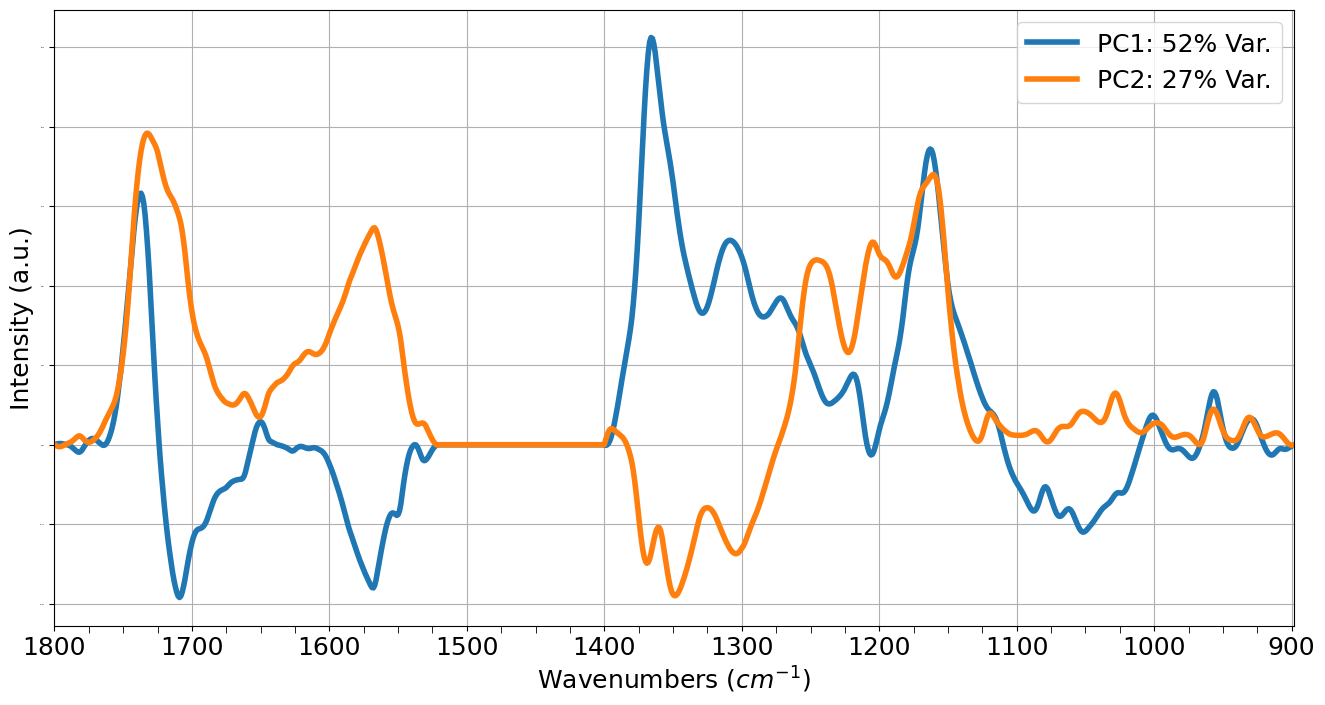

In [50]:
filepath = "C:/Users/Zach/Documents/GitHub/Feature Extraction/KMeans_Feature_Extraction/training_data.csv"
training_df = pd.read_csv(filepath, low_memory=True)
wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])
PC_inputData = training_df[wavenumbers].values

PCs = 2

PCA_output = IR_PCA(PC_inputData, PCs, normalize=False)

PC_df = PCA_output[0]
loadings_df = PCA_output[1]
PC_df['Sample Name'] = training_df['Sample Name']

fig, ax = plt.subplots(figsize=(16, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster2_spectra)))
for i in range(len(loadings_df)):
    ax.plot(frequencies, loadings_df.iloc[i], linewidth=4)

ax.set_ylabel('Intensity (a.u.)', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)

ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))

ax.legend(labels=['PC1: 52% Var.', 'PC2: 27% Var.'],
        fontsize=18, loc='upper right', 
        bbox_to_anchor=(0.5, 0.5, 0.5, 0.5))

ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.grid(True)

